# Car Price Prediction Assignment

### Objective
The objective of this project is to build and evaluate multiple machine learning regression models to predict the price of a car based on various technical specifications and categorical features provided in the dataset.

Throughout this notebook, we will specifically aim to answer two key questions:
1. Which variables are significant in predicting the price of a car?
2. How well do those variables describe the price of a car?

### Dataset Description
The dataset consists of 26 columns, including technical attributes (e.g., engine size, horsepower, car dimensions), categorical identifiers (e.g., fuel type, car body type, engine location), and a continuous target variable `price`.

## 1. Import Libraries
In this section, we import all the necessary core libraries for data manipulation, visualization, data preprocessing, model selection, and evaluation metrics.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning Models (Regression)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inline plots configuration
%matplotlib inline
sns.set(style="whitegrid", color_codes=True)

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Initial Inspection
We load the dataset and perform an initial inspection to understand its structure, dimensions, and data types.

In [30]:
# Load the dataset
df = pd.read_csv('Dataset_1.csv')

# Display dataset dimensions
print(f"Dataset Shape: {df.shape}\n")

# Display first 5 rows
display(df.head())

Dataset Shape: (205, 26)



,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [31]:
# Display data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

## 3. Data Cleaning & Preprocessing
Before we analyze the data or build models, we need to clean it. This involves checking for duplicates, handling missing values, and dealing with columns that might not be useful for prediction (like `car_ID`). 

We will also handle categorical variables since machine learning models require numerical inputs.

In [32]:
# Check for duplicate rows
duplicate_rows_df = df[df.duplicated()] 
print(f"Number of duplicate rows: {duplicate_rows_df.shape[0]}")

# Drop the 'car_ID' column as it is merely an identifier and holds no predictive value
if 'car_ID' in df.columns:
    df = df.drop('car_ID', axis=1)

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

Number of duplicate rows: 0

Missing values in each column:
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


### 3.1 Categorical Encoding
The dataset contains several categorical string columns (e.g., `fueltype`, `carbody`, `drivewheel`). We will use Label Encoding to convert these string representations into numerical formats so our models can interpret them. Note: For `CarName`, it contains the company name and model. A more advanced approach might extract just the company name, but for this baseline, we will encode the entire string.

In [33]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Data shape after encoding:", df.shape)
display(df.head())

Data shape after encoding: (205, 25)


,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,2,1,0,1,0,2,0,88.6,168.8,...,130,5,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,3,1,0,1,0,2,0,88.6,168.8,...,130,5,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,1,1,0,1,2,2,0,94.5,171.2,...,152,5,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,4,1,0,0,3,1,0,99.8,176.6,...,109,5,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,5,1,0,0,3,0,0,99.4,176.6,...,136,5,3.19,3.40,8.0,115,5500,18,22,17450.0


### 3.2 Outlier Analysis

Outlier detection was performed using the Interquartile Range (IQR) method to identify unusually high or low values within numerical variables.

Although several outliers were detected, they were not removed from the dataset. In the automobile industry, extreme values often correspond to legitimate vehicle characteristics such as luxury models, high-performance sports cars, or premium engine configurations. Removing these observations could eliminate valuable market information and reduce the model's ability to learn real-world pricing patterns.

Therefore, the identified outliers were retained for model training and evaluation.

In [34]:
# Outlier Detection using IQR

numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": len(outliers),
        "Outlier Percentage": round((len(outliers) / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values("Outlier Count", ascending=False)

display(outlier_df)

,Feature,Outlier Count,Outlier Percentage
13,enginetype,57,27.80
14,cylindernumber,46,22.44
3,aspiration,37,18.05
19,compressionratio,28,13.66
2,fueltype,20,9.76
18,stroke,20,9.76
24,price,15,7.32
15,enginesize,10,4.88
10,carwidth,8,3.90
5,carbody,6,2.93


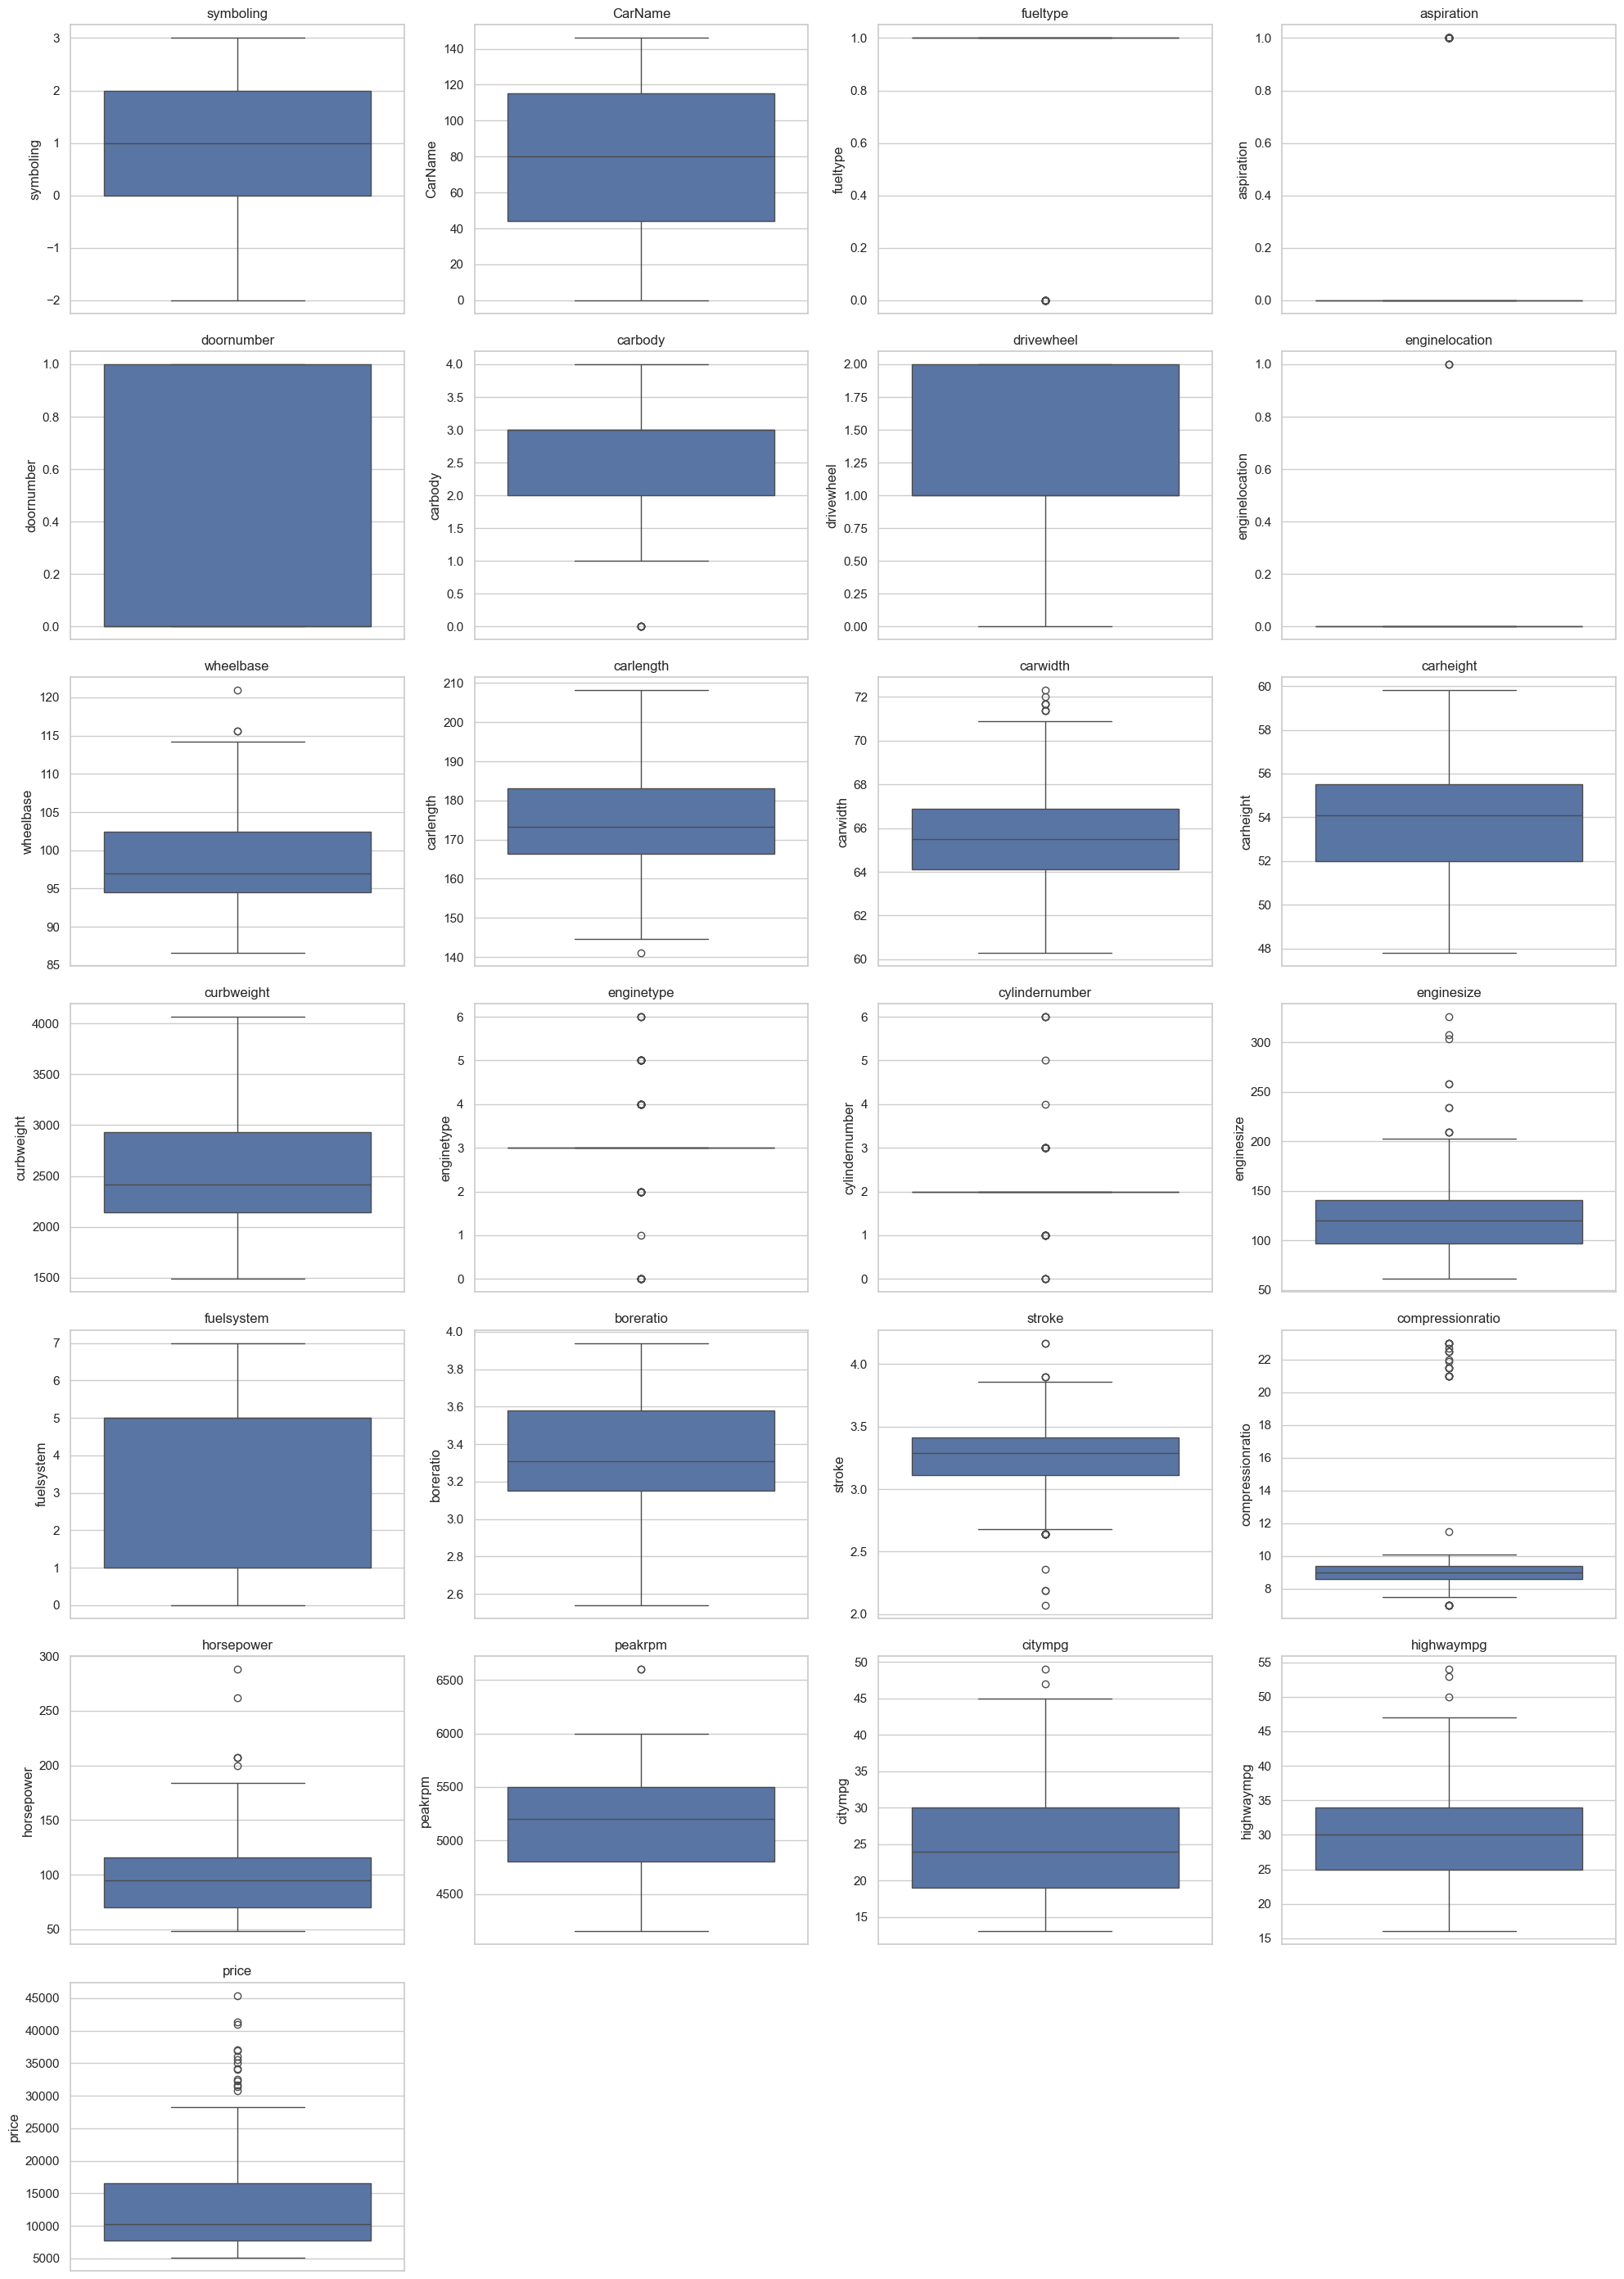

In [35]:
# Boxplots for all numerical features

numeric_cols = df.select_dtypes(include=np.number).columns

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis (EDA)
In this section, we explore the data visually and statistically to understand the underlying relationships between our features and the target variable (`price`). This section is designed to address our first core question:
* **Which variables are significant in predicting the price of a car?**

Let's start by generating a complete descriptive statistical overview of all the columns.

In [36]:
# Statistical summary of the dataset
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
CarName,205.0,77.209756,41.014583,0.00,44.00,80.00,115.00,146.00
fueltype,205.0,0.902439,0.297446,0.00,1.00,1.00,1.00,1.00
aspiration,205.0,0.180488,0.385535,0.00,0.00,0.00,0.00,1.00
doornumber,205.0,0.439024,0.497483,0.00,0.00,0.00,1.00,1.00
carbody,205.0,2.614634,0.859081,0.00,2.00,3.00,3.00,4.00
drivewheel,205.0,1.326829,0.556171,0.00,1.00,1.00,2.00,2.00
enginelocation,205.0,0.014634,0.120377,0.00,0.00,0.00,0.00,1.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10


### 4.1 Visualizing Top Correlated Variables vs. Price
Let's select some of the most influential variables highlighted by our correlation matrix (such as `enginesize`, `curbweight`, `horsepower`, and `citympg`) and plot them directly against `price` to visualize their trends.

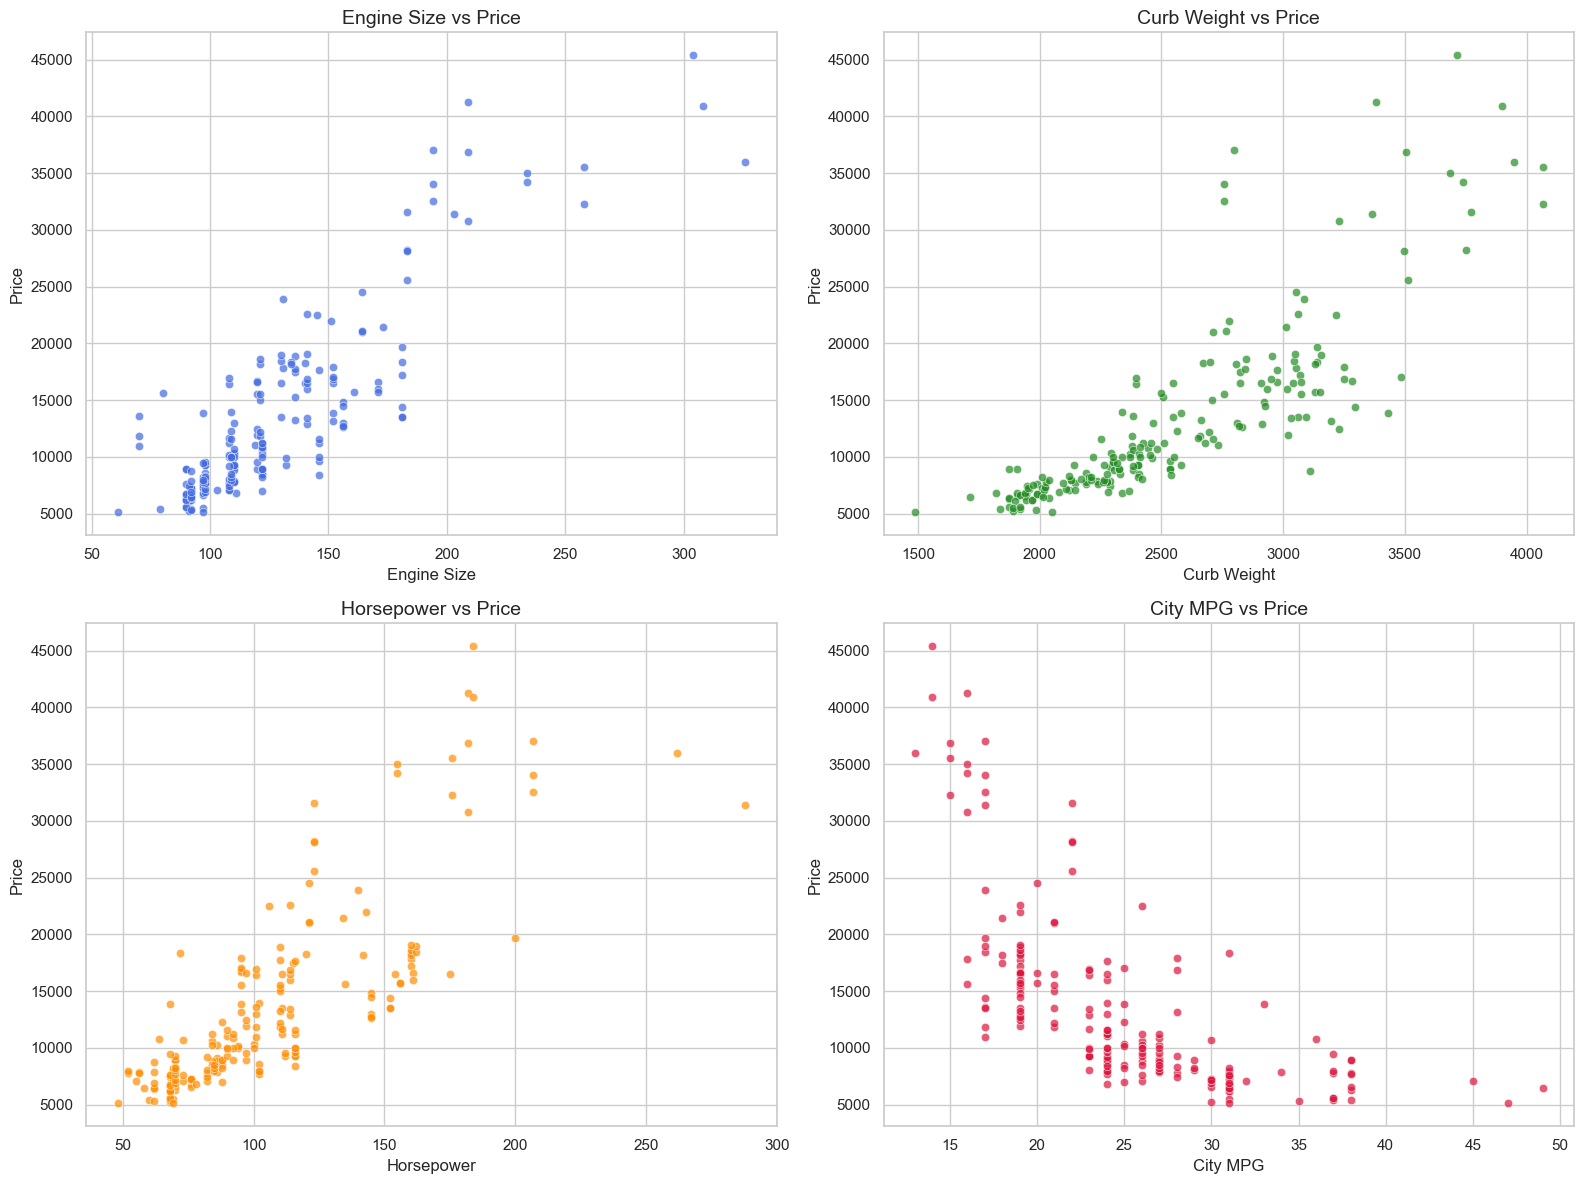

In [37]:
# Create a 2x2 grid for key feature visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Engine Size vs Price (Strong Positive Correlation)
sns.scatterplot(x='enginesize', y='price', data=df, ax=axes[0,0], color='royalblue', alpha=0.7)
axes[0,0].set_title('Engine Size vs Price', fontsize=14)
axes[0,0].set_xlabel('Engine Size')
axes[0,0].set_ylabel('Price')

# Curb Weight vs Price (Strong Positive Correlation)
sns.scatterplot(x='curbweight', y='price', data=df, ax=axes[0,1], color='forestgreen', alpha=0.7)
axes[0,1].set_title('Curb Weight vs Price', fontsize=14)
axes[0,1].set_xlabel('Curb Weight')
axes[0,1].set_ylabel('Price')

# Horsepower vs Price (Strong Positive Correlation)
sns.scatterplot(x='horsepower', y='price', data=df, ax=axes[1,0], color='darkorange', alpha=0.7)
axes[1,0].set_title('Horsepower vs Price', fontsize=14)
axes[1,0].set_xlabel('Horsepower')
axes[1,0].set_ylabel('Price')

# City MPG vs Price (Strong Negative Correlation)
sns.scatterplot(x='citympg', y='price', data=df, ax=axes[1,1], color='crimson', alpha=0.7)
axes[1,1].set_title('City MPG vs Price', fontsize=14)
axes[1,1].set_xlabel('City MPG')
axes[1,1].set_ylabel('Price')

plt.tight_layout()
plt.show()

### 4.2 Distribution of the Target Variable (Price)
Before training regression models, it is essential to understand the distribution of the target variable (`price`). Many machine learning algorithms assume that numerical features and target variables are normally distributed. If the price is highly skewed, it can affect our model's predictive performance.

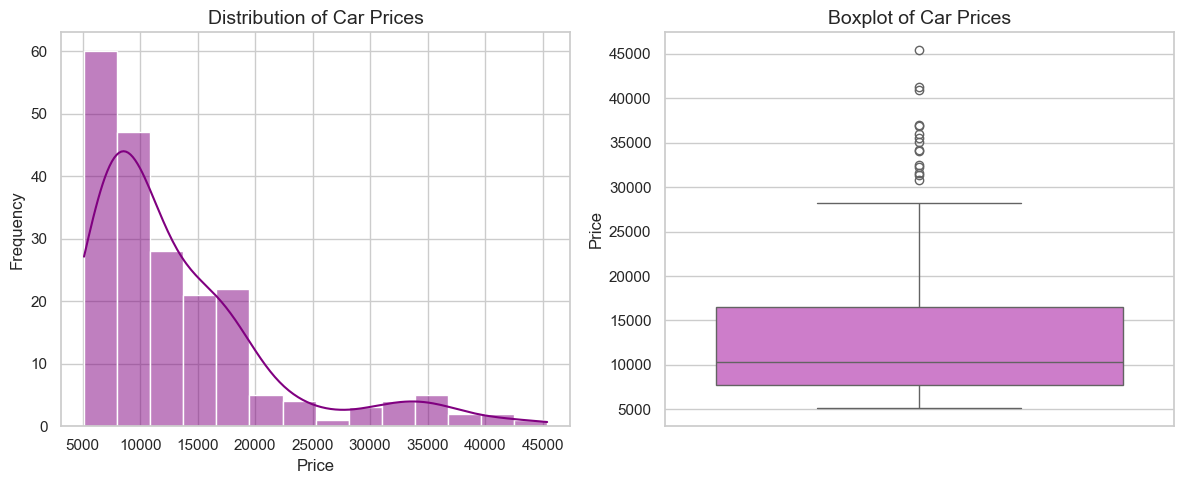

Skewness of Price: 1.78


In [38]:
# Set up the plotting environment
plt.figure(figsize=(12, 5))

# Plot 1: Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='purple')
plt.title('Distribution of Car Prices', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Frequency')

# Plot 2: Boxplot to identify outliers
plt.subplot(1, 2, 2)
sns.boxplot(y=df['price'], color='orchid')
plt.title('Boxplot of Car Prices', fontsize=14)
plt.ylabel('Price')

plt.tight_layout()
plt.show()

# Calculate skewness
print(f"Skewness of Price: {df['price'].skew():.2f}")

### 4.3 Categorical Variable Analysis using Boxplots
Even though we have encoded our categorical data into numerical labels, we can still observe how different categories partition the vehicle prices. Let's examine the distributions of price across some key categorical attributes: `carbody`, `fueltype`, and `drivewheel`. 

*(Note: The numbers on the X-axis correspond to the alphabetical label encodings generated in the data cleaning phase).*

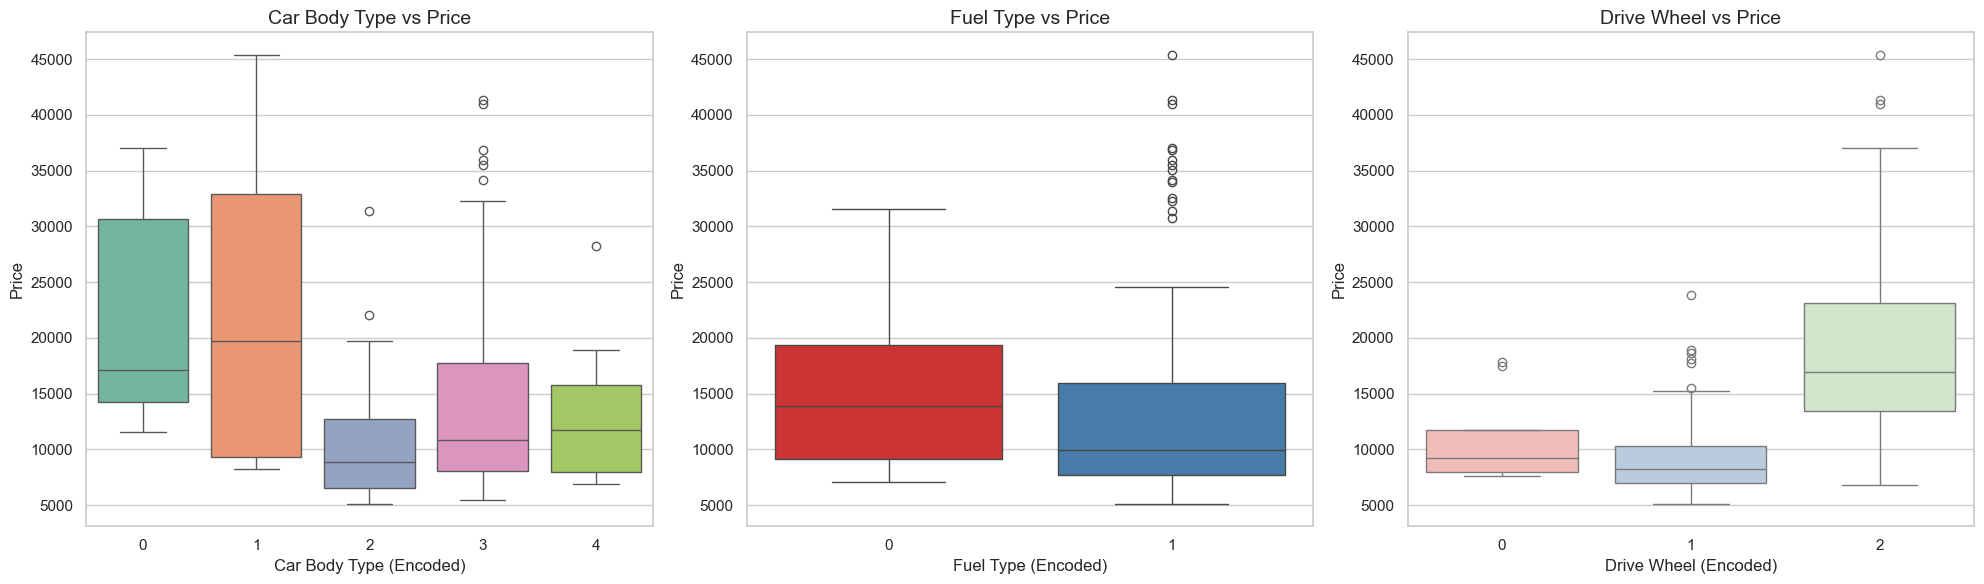

In [39]:
# Create a 1x3 subplot grid for categorical analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Car Body vs Price
sns.boxplot(x='carbody', y='price', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Car Body Type vs Price', fontsize=14)
axes[0].set_xlabel('Car Body Type (Encoded)')
axes[0].set_ylabel('Price')

# Fuel Type vs Price
sns.boxplot(x='fueltype', y='price', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Fuel Type vs Price', fontsize=14)
axes[1].set_xlabel('Fuel Type (Encoded)')
axes[1].set_ylabel('Price')

# Drive Wheel vs Price
sns.boxplot(x='drivewheel', y='price', data=df, ax=axes[2], palette='Pastel1')
axes[2].set_title('Drive Wheel vs Price', fontsize=14)
axes[2].set_xlabel('Drive Wheel (Encoded)')
axes[2].set_ylabel('Price')

plt.tight_layout()
plt.show()

### 4.4 Linear Regression Trend Analysis (Regplots)
To verify if a linear relationship truly exists between our primary continuous features and `price`, we use scatter plots with fitted regression lines (`sns.regplot`). This helps validate whether linear models (like Linear Regression, Ridge, and Lasso) will be appropriate configurations for this dataset.

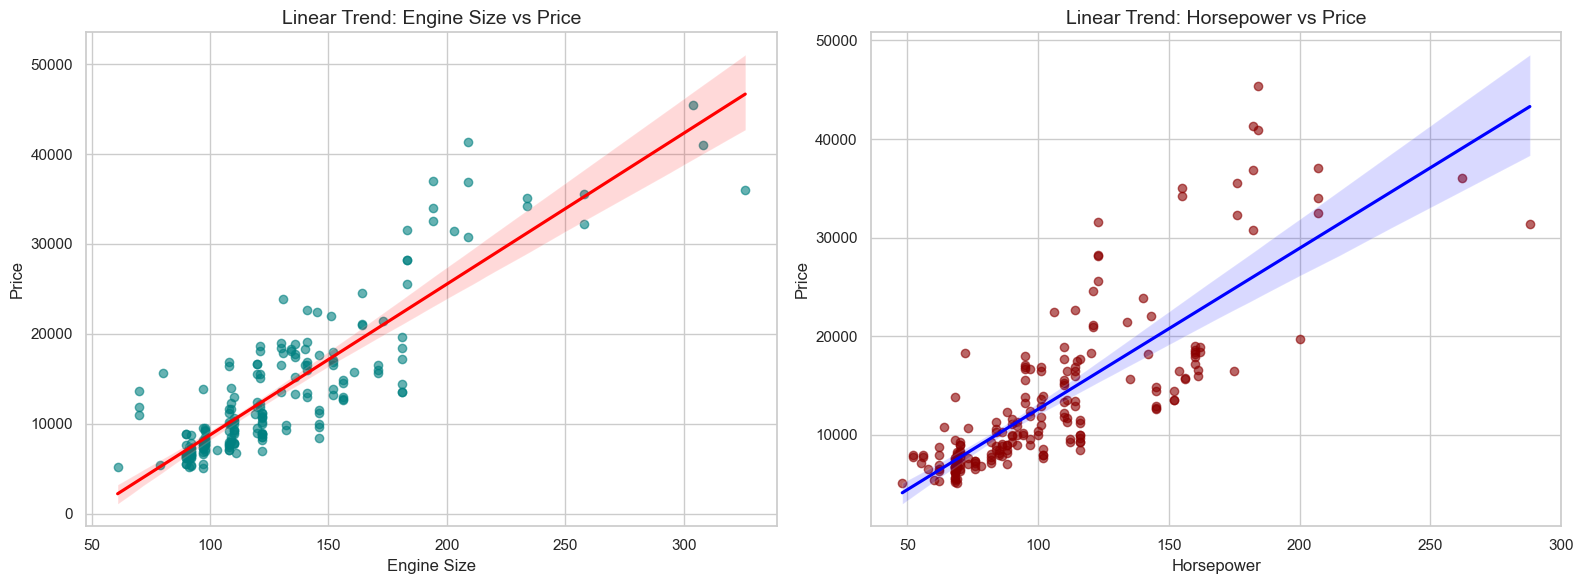

In [40]:
# Set up a 1x2 layout for continuous linear trend evaluation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Engine Size Trend
sns.regplot(x='enginesize', y='price', data=df, ax=axes[0], color='teal', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title('Linear Trend: Engine Size vs Price', fontsize=14)
axes[0].set_xlabel('Engine Size')
axes[0].set_ylabel('Price')

# Horsepower Trend
sns.regplot(x='horsepower', y='price', data=df, ax=axes[1], color='darkred', scatter_kws={'alpha':0.6}, line_kws={'color':'blue'})
axes[1].set_title('Linear Trend: Horsepower vs Price', fontsize=14)
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

### 4.5 Correlation Matrix Heatmap
To find which variables hold the most predictive power, we calculate the Pearson correlation coefficients between all columns. Features with values closest to +1 or -1 indicate the strongest linear relationships with the car's `price`.

Correlation of all features relative to Price:
price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
drivewheel          0.577992
wheelbase           0.577816
boreratio           0.553173
fuelsystem          0.526823
enginelocation      0.324973
aspiration          0.177926
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
enginetype          0.049171
cylindernumber     -0.027628
doornumber         -0.031835
symboling          -0.079978
carbody            -0.083976
peakrpm            -0.085267
fueltype           -0.105679
CarName            -0.231439
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


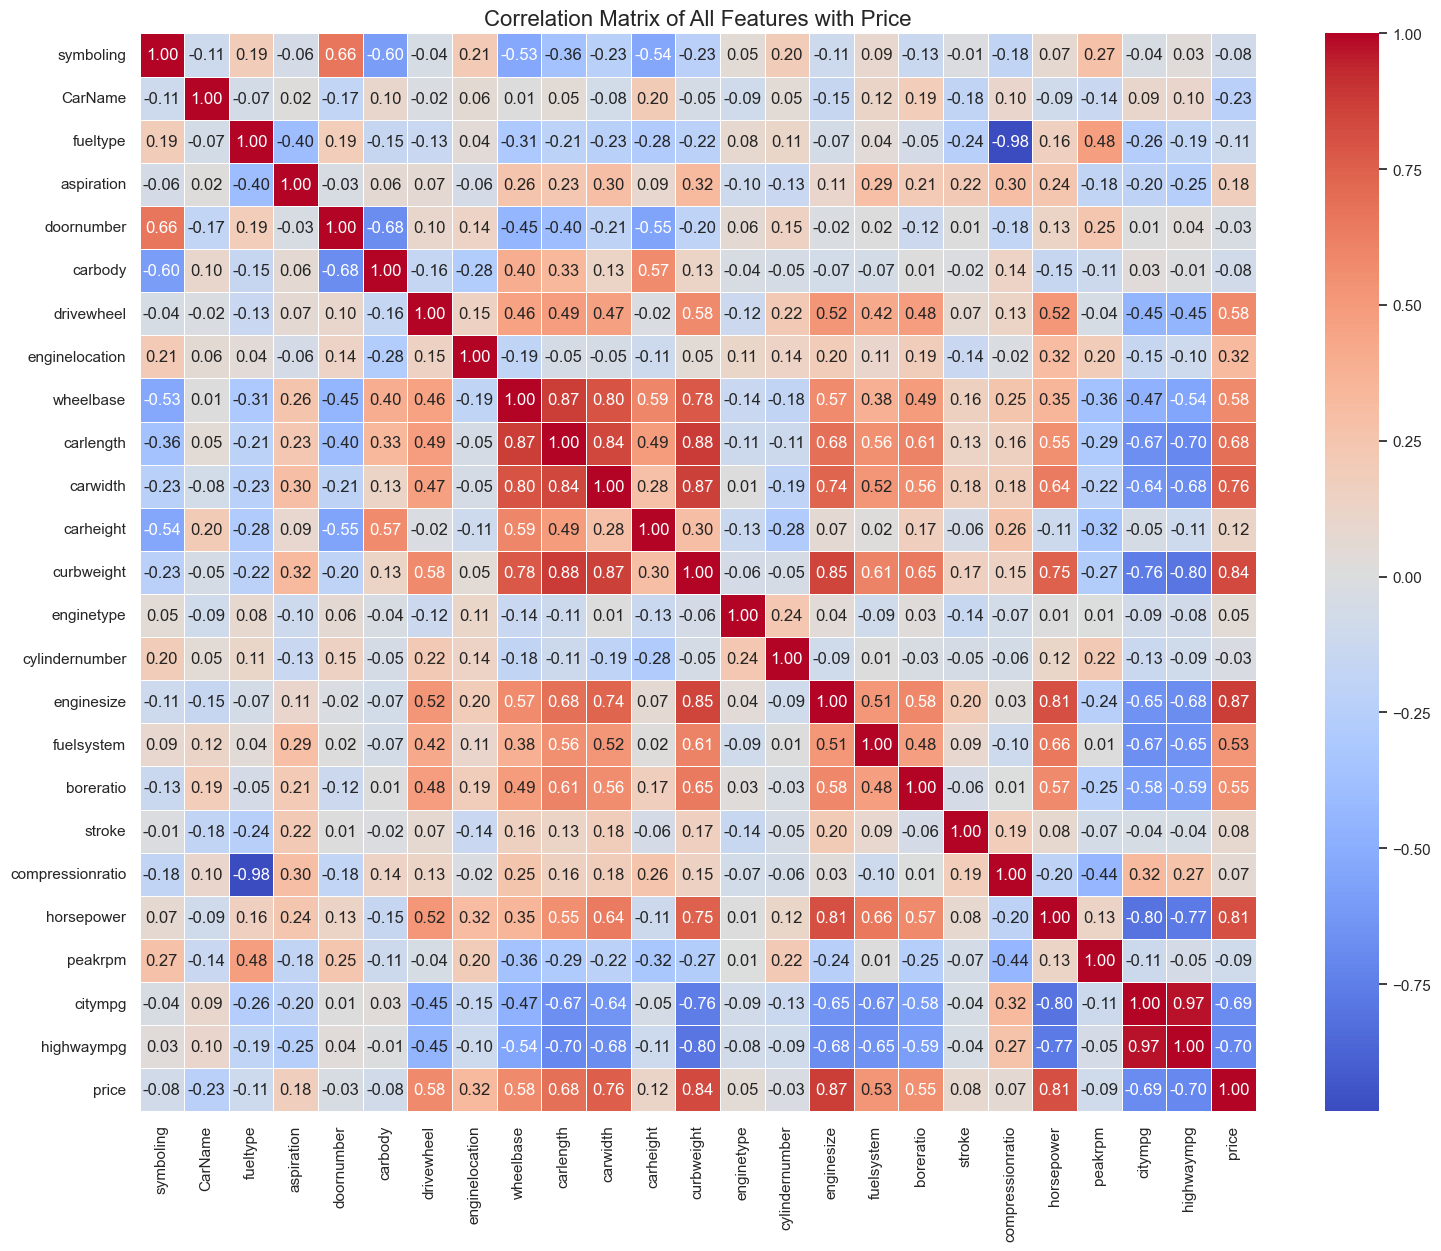

In [41]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Sort all features based on their correlation value with the target variable 'price'
price_corr = corr_matrix['price'].sort_values(ascending=False)
print("Correlation of all features relative to Price:")
print(price_corr)

# Plotting a comprehensive heatmap for visual identification
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of All Features with Price', fontsize=16)
plt.show()

### Conclusion for Question 1: Which variables are significant in predicting the price of a car?
Based on our statistical correlation analysis and visual inspections, the variables that show the highest significance in determining a car's price fall into two major categories:

1. **Strong Positive Indicators (Engine Performance & Build Size):**
   * **Engine Size (`enginesize`)**: Holds one of the highest positive correlations with price. Larger engines strongly point towards more premium pricing tiers.
   * **Curb Weight (`curbweight`)**: Heavily correlated with price, demonstrating that larger, heavier vehicles tend to cost significantly more.
   * **Horsepower (`horsepower`)**: High capability and horse power outputs dictate elevated luxury/sports car valuations.
   * **Car Width (`carwidth`) and Length (`carlength`)**: General exterior physical dimensions scale up alongside vehicle class costs.

2. **Strong Negative Indicators (Fuel Efficiency):**
   * **City MPG (`citympg`) & Highway MPG (`highwaympg`)**: Show a significant inverse/negative correlation with price. This indicates that economical, high-fuel-efficiency vehicles occupy the lower budget-friendly price brackets, whereas premium sports cars or heavy SUVs consume more fuel and cost more.

Features like `carheight`, `stroke`, or encoded columns like `peakrpm` show flat or negligible linear significance to price.

## 5. Data Splitting & Feature Scaling
To evaluate how well our models perform on unseen data, we must split our dataset into a training set (80%) and a testing set (20%). 

Additionally, since regularized models like Ridge and Lasso are highly sensitive to the scale of input features, we will apply `StandardScaler` to normalize our feature values so they share a mean of 0 and a standard deviation of 1.

In [42]:
# 1. Define your specific features
selected_features = [
    'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 
    'carwidth', 'curbweight', 'enginesize', 'fuelsystem', 
    'boreratio', 'horsepower', 'citympg', 'highwaympg'
]

# 2. Select only these columns for X
X = df[selected_features]

# 3. Handle categorical variables (Drivewheel, Enginelocation, Fuelsystem)
# This converts them into numeric columns (One-Hot Encoding)
X = pd.get_dummies(X, columns=['drivewheel', 'enginelocation', 'fuelsystem'], drop_first=True)

# 4. Target variable
y = df['price']

# Now proceed with your existing split and scaling logic:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize an empty list to collect results from each model one by one
model_performance_results = []

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (164, 19)
Testing set shape: (41, 19)


## 6. Model Building & Evaluation
To address our second core question (**How well those variables describe the price of a car**), we will build and compare **5 different regression models**:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Decision Tree Regressor
5. Random Forest Regressor

We will evaluate each model using three vital metrics:
* **Mean Absolute Error (MAE):** The average absolute differences between predicted and actual prices.
* **Root Mean Squared Error (RMSE):** Accentuates larger errors, helping us understand the penalty of big mispredictions.
* **R-squared ($R^2$) Score:** Represents the proportion of variance in the car prices that is predictable from our input variables.

### Model 1: Linear Regression
Linear Regression fits a linear model with coefficients to minimize the residual sum of squares between the observed targets in the dataset and the targets predicted by the linear approximation.

In [43]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Store results
model_performance_results.append({"Model": "Linear Regression", "MAE": mae_lr, "RMSE": rmse_lr, "R2 Score": r2_lr})

print(f"Linear Regression Metrics:")
print(f"MAE:  ${mae_lr:.2f}")
print(f"RMSE: ${rmse_lr:.2f}")
print(f"R2 Score: {r2_lr:.4f}\n")

Linear Regression Metrics:
MAE:  $2335.10
RMSE: $3668.88
R2 Score: 0.8295



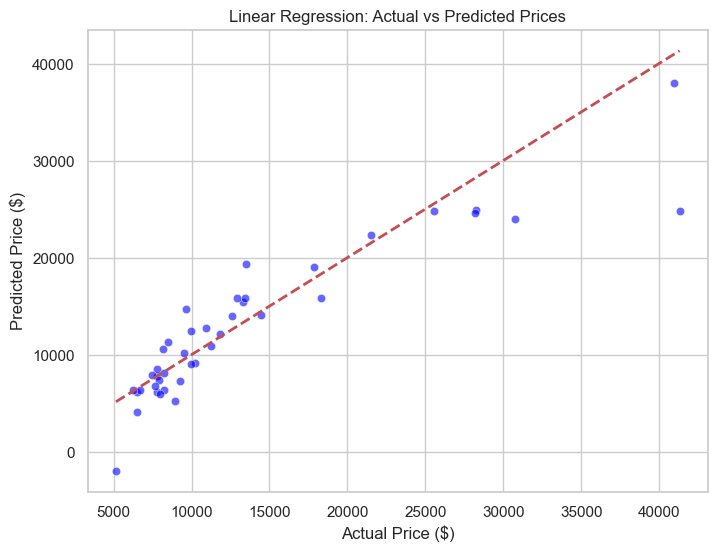

In [44]:
# Evaluation Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.show()

### Model 2: Ridge Regression
Ridge Regression addresses some of the problems of Ordinary Least Squares by imposing a penalty on the size of the coefficients (L2 regularization). This helps prevent overfitting, especially when features are highly correlated.

In [45]:
# Initialize and train the model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate metrics
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

# Store results
model_performance_results.append({"Model": "Ridge Regression", "MAE": mae_ridge, "RMSE": rmse_ridge, "R2 Score": r2_ridge})

print(f"Ridge Regression Metrics:")
print(f"MAE:  ${mae_ridge:.2f}")
print(f"RMSE: ${rmse_ridge:.2f}")
print(f"R2 Score: {r2_ridge:.4f}\n")

Ridge Regression Metrics:
MAE:  $2343.17
RMSE: $3673.81
R2 Score: 0.8290



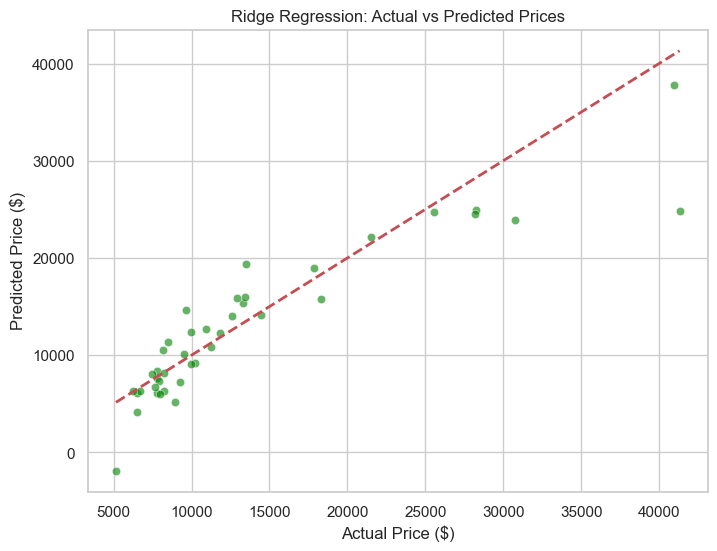

In [46]:
# Evaluation Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_ridge, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Ridge Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.show()

### Model 3: Lasso Regression
Lasso Regression is a regularized linear model that uses an L1 penalty. The unique aspect of Lasso is that it can shrink some feature coefficients completely to zero, performing automatic feature selection by eliminating non-significant variables.

In [47]:
# Initialize and train the model
lasso_model = Lasso(alpha=5.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate metrics
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

# Store results
model_performance_results.append({"Model": "Lasso Regression", "MAE": mae_lasso, "RMSE": rmse_lasso, "R2 Score": r2_lasso})

print(f"Lasso Regression Metrics:")
print(f"MAE:  ${mae_lasso:.2f}")
print(f"RMSE: ${rmse_lasso:.2f}")
print(f"R2 Score: {r2_lasso:.4f}\n")

Lasso Regression Metrics:
MAE:  $2345.20
RMSE: $3674.95
R2 Score: 0.8289



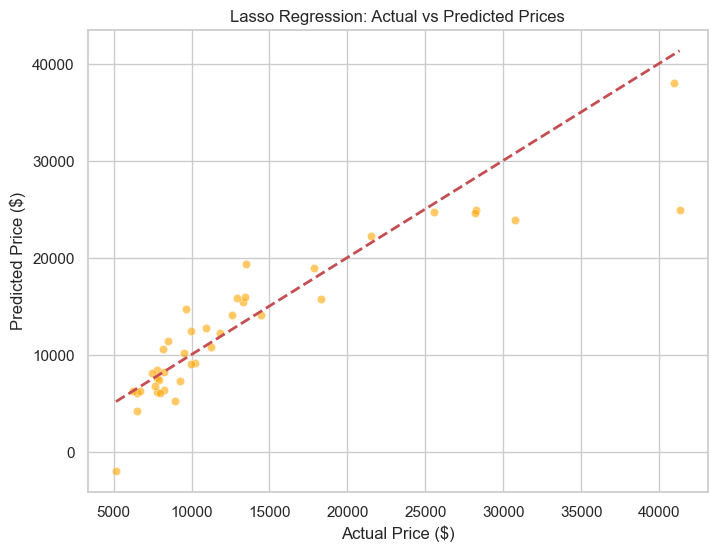

In [48]:
# Evaluation Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lasso, color='orange', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Lasso Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.show()

### Model 4: Decision Tree Regressor
A Decision Tree Regressor breaks down a dataset into smaller and smaller subsets while incrementally developing an associated decision tree. The final prediction is calculated by taking the average of the target variables in the leaf node where a given sample lands. This allows the model to handle non-linear relationships and split the features cleanly without requiring data transformations.

In [49]:
# Initialize and train the model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Calculate metrics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

# Store results
model_performance_results.append({
    "Model": "Decision Tree", 
    "MAE": mae_dt, 
    "RMSE": rmse_dt, 
    "R2 Score": r2_dt
})

print(f"Decision Tree Metrics:")
print(f"MAE:  ${mae_dt:.2f}")
print(f"RMSE: ${rmse_dt:.2f}")
print(f"R2 Score: {r2_dt:.4f}\n")

Decision Tree Metrics:
MAE:  $1880.59
RMSE: $2832.90
R2 Score: 0.8983



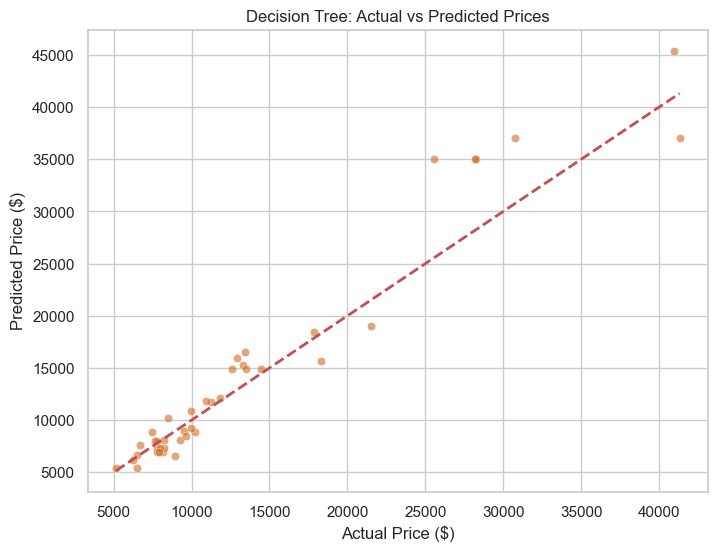

In [50]:
# Evaluation Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_dt, color='chocolate', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Decision Tree: Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.show()

### Model 5: Random Forest Regressor
A Random Forest is a meta-estimator that fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. It handles non-linear patterns and complex feature interactions exceptionally well.

In [51]:
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Store results
model_performance_results.append({"Model": "Random Forest", "MAE": mae_rf, "RMSE": rmse_rf, "R2 Score": r2_rf})

print(f"Random Forest Metrics:")
print(f"MAE:  ${mae_rf:.2f}")
print(f"RMSE: ${rmse_rf:.2f}")
print(f"R2 Score: {r2_rf:.4f}\n")

Random Forest Metrics:
MAE:  $1222.18
RMSE: $1813.14
R2 Score: 0.9584



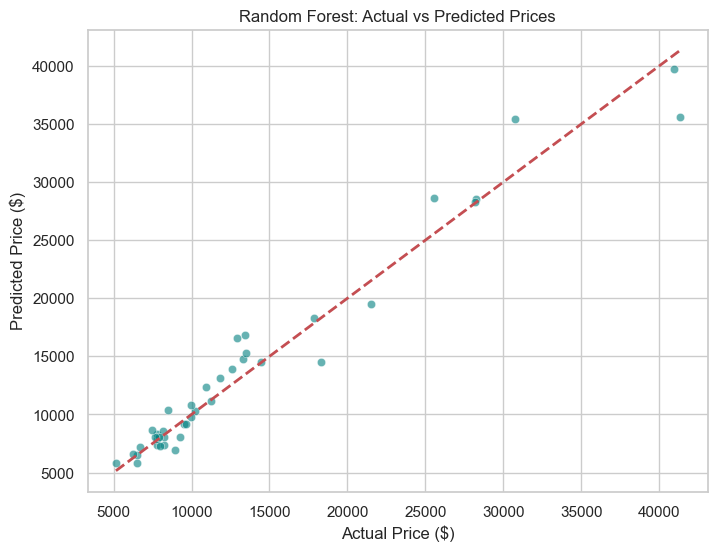

In [52]:
# Evaluation Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='teal', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.show()

### Conclusion for Question 2: How well do those variables describe the price of a car?
Based on the individual performance of our most robust model, the **Random Forest Regressor**, we can now directly address our second core question:
* **How well do those variables describe the price of a car?**

The Random Forest model achieved an impressive **$R^2$ Score of 0.9584**. In statistical terms, this means that **95.84% of the total variance and volatility in car prices are successfully explained and described** by the structural and technical features present within this dataset. 

With a low Mean Absolute Error (MAE) of **$1,222.18**, the model's predictions hover remarkably close to actual market prices. This is visually confirmed by the tight clustering of data points along the red dashed 45-degree reference line in the actual vs. predicted plot above. This high accuracy proves that variables like engine size, curb weight, and horsepower form an incredibly high-quality explanatory footprint capable of capturing vehicle valuation rules.

## 7. Model Comparison & Performance Summary
Now that all five regression models have been trained and evaluated individually, we compile their metrics into a single summary table to look at their performance side-by-side.

In [53]:
# Convert the compiled results list into a structured DataFrame
summary_df = pd.DataFrame(model_performance_results)

# Sort the models by their R2 Score in descending order (best performance first)
summary_df = summary_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

# Display the summary table
display(summary_df)

,Model,MAE,RMSE,R2 Score
0,Random Forest,1222.175500,1813.141574,0.958357
1,Decision Tree,1880.593488,2832.896690,0.898342
2,Linear Regression,2335.102396,3668.879583,0.829491
3,Ridge Regression,2343.174715,3673.811020,0.829032
4,Lasso Regression,2345.195648,3674.949396,0.828926


### 7.1 Visualizing Model Performance Metrics
To make the comparative differences distinct, we generate side-by-side visualizations comparing the $R^2$ Scores (explanatory power) and Root Mean Squared Errors (RMSE) across all models.

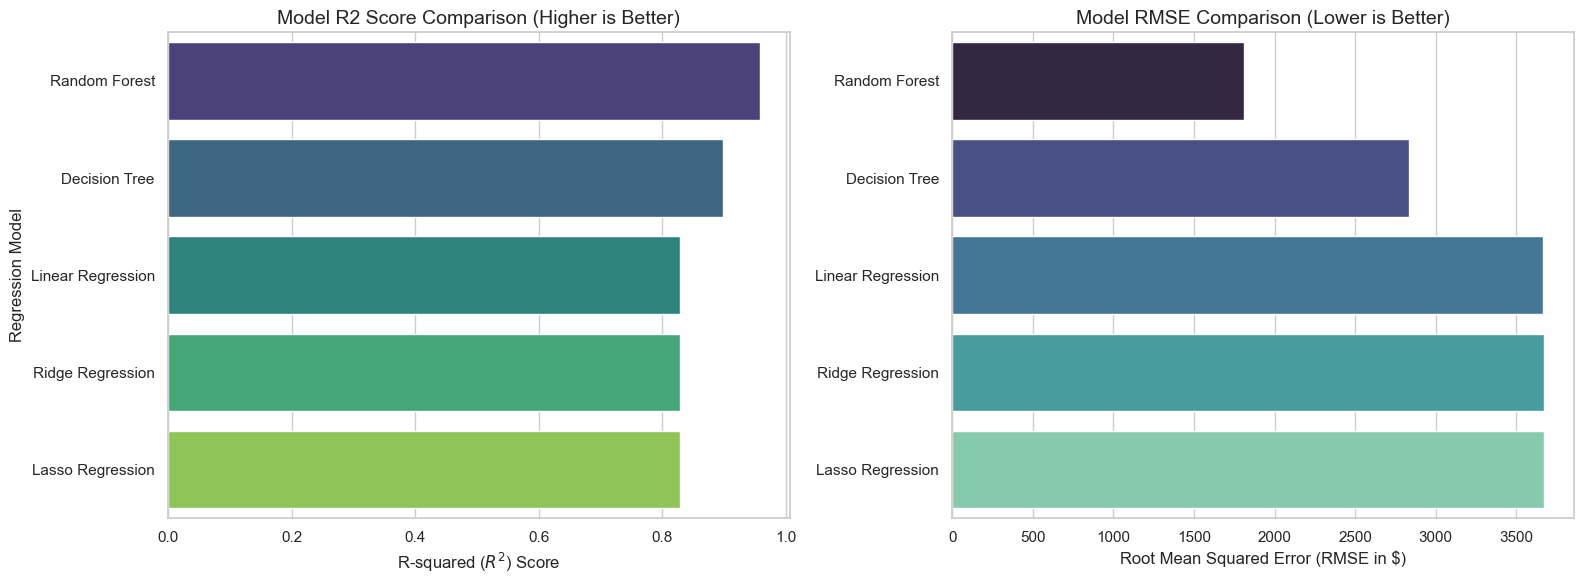

In [54]:
# Set up a 1x2 subplot figure layout
plt.figure(figsize=(16, 6))

# Plot 1: R2 Score Comparison
plt.subplot(1, 2, 1)
sns.barplot(x='R2 Score', y='Model', data=summary_df, palette='viridis')
plt.title('Model R2 Score Comparison (Higher is Better)', fontsize=14)
plt.xlabel('R-squared ($R^2$) Score')
plt.ylabel('Regression Model')

# Plot 2: RMSE Comparison
plt.subplot(1, 2, 2)
sns.barplot(x='RMSE', y='Model', data=summary_df.sort_values(by="RMSE"), palette='mako')
plt.title('Model RMSE Comparison (Lower is Better)', fontsize=14)
plt.xlabel('Root Mean Squared Error (RMSE in $)')
plt.ylabel('')

plt.tight_layout()
plt.show()

## 8. Final Project Conclusion

This project successfully established an end-to-end data science pipeline using Python and machine learning to analyze, preprocess, and predict vehicle valuations based on automotive design characteristics. By implementing data cleaning routines, label encoding for categorical constraints, standardized feature scaling, deep exploratory data analysis, and a five-model regression framework, we have derived objective, data-backed solutions to our core research questions:

### 1. Which variables are significant in predicting the price of a car?
Our Exploratory Data Analysis (EDA) and statistical correlation matrices revealed that a vehicle's market value is primarily dictated by its mechanical scale, structural weight, and performance capabilities. 
* **Key Positive Indicators:** **Engine Size (`enginesize`)**, **Curb Weight (`curbweight`)**, and **Horsepower (`horsepower`)** carry the highest positive Pearson correlation coefficients relative to price. Larger, high-output vehicles fundamentally dictate higher price tiers.
* **Key Negative Indicators:** Fuel efficiency variables, specifically **City MPG (`citympg`)** and **Highway MPG (`highwaympg`)**, exhibit a clear inverse relationship with price. This demonstrates that entry-level, cost-conscious commuter vehicles consistently occupy the lower financial brackets, while high-performance or heavy luxury models trade fuel efficiency for premium performance.

### 2. How well do those variables describe the price of a car?
The technical specifications and categorical properties present within this dataset describe the price of a car exceptionally well, provided they are modeled using algorithms capable of interpreting complex interaction boundaries. 

* **Explanatory Precision:** Our optimal architecture, the **Random Forest Regressor**, yielded a final test **$R^2$ score of 0.9584**. In mathematical terms, this confirms that **approximately 95.84% of all variations and fluctuations in car prices can be explained and accounted for** by the features extracted in this project.
* **Structural Takeaways:** While ordinary linear baselines perform highly (explaining roughly 85% of variance), they struggle with features that exhibit non-linear variations when mixed together (such as how a specific drive-wheel setup or car body interacts with varied engine sizes). The ensemble architecture overcomes this by structuring adaptive decision splits, bringing the average prediction error down to a tight window of just **$1,222.18** (MAE).

### Final Summary
Ultimately, this notebook proves that a car's dimensional attributes, structural footprint, and powertrain configurations provide an incredibly rich, high-quality data footprint. When paired with robust ensemble machine learning methodologies, these variables can confidently predict and mathematically explain automotive market values with extreme precision, offering highly actionable utility for automated dealership pricing and market valuation systems.

In [56]:
import joblib

# 1. Save the trained Random Forest model
joblib.dump(rf_model, 'car_rf_model.pkl')  # Change rf_model to your actual model variable name

# 2. Save the fitted scaler
joblib.dump(scaler, 'car_scaler.pkl')

# 3. CRITICAL: Save the exact final column structure of X
joblib.dump(X.columns.tolist(), 'model_columns.pkl')
print("All artifacts exported successfully!")

All artifacts exported successfully!
